In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Definición de la función para calcular la divergencia KL entre dos distribuciones discretas
def kl_discrete(p, q):
    """
    Calcula la divergencia Kullback-Leibler (KL) entre dos distribuciones de probabilidad discretas.

    Args:
        p (np.array): Distribución de probabilidad "verdadera" o empírica.
        q (np.array): Distribución de probabilidad "aproximada" o modelo.

    Returns:
        float: La divergencia KL.
    """
    # Asegurar que las distribuciones son arrays de numpy
    p = np.asarray(p)
    q = np.asarray(q)

    # Evitar logaritmos de cero; reemplazar valores cero con un número muy pequeño
    # para evitar divisiones por cero en q y log(0) en p. log(0) debería dar infinito.
    # Para la KL divergencia, si p(i) > 0 y q(i) = 0, la KL divergencia es infinita.
    # Aquí, simplemente filtramos los puntos donde p es cero o q es cero para el cálculo.
    # Una aproximación común es añadir un pequeño epsilon, pero para p log (p/q),
    # si p_i es 0, el término es 0. Si q_i es 0, el término es infinito si p_i > 0.
    # Usaremos una máscara para solo considerar los elementos donde p > 0 y q > 0
    mask = (p > 0) & (q > 0)
    if not np.all(mask):
        print("Advertencia: Algunos valores en p o q son cero. La divergencia KL puede ser infinita o aproximada.")

    return np.sum(p[mask] * np.log(p[mask] / q[mask]))

Vamos a lanzar un dado num_thorws veces. Esto nos permitirá calcular la probabilidad empírica y la compararemos con la distribución teórica. Se podrá observar que a medida que hay más datos, la probabilidad empírica será más cercana (distancia que tiende a 0). 

In [7]:
# 1. Simular 20 lanzamientos de un dado de 6 caras
num_throws = 1000
die_rolls = np.random.randint(1, 7, num_throws) # Dado de 6 caras (1 a 6)
#print(f"Lanzamientos del dado ({num_throws}): {die_rolls}")

# 2. Calcular la probabilidad experimental
# Contar las ocurrencias de cada cara
counts = pd.Series(die_rolls).value_counts().sort_index()

# Asegurarse de que todas las caras (1-6) estén presentes, incluso si no aparecieron
all_faces = np.arange(1, 7)
experimental_counts = counts.reindex(all_faces, fill_value=0)

# Calcular probabilidades experimentales
experimental_probs = experimental_counts / num_throws

print("\nProbabilidad experimental:")
print(experimental_probs)

# 3. Definir la distribución uniforme teórica para un dado de 6 caras
uniform_probs = np.full(6, 1/6)

print("\nProbabilidad uniforme teórica:")
print(uniform_probs)

# 4. Calcular la distancia de KL
kl_divergence = kl_discrete(experimental_probs.values, uniform_probs)

print(f"\nDistancia de KL (Experimental vs Uniforme): {kl_divergence:.6f}")


Probabilidad experimental:
1    0.166
2    0.154
3    0.166
4    0.169
5    0.180
6    0.165
Name: count, dtype: float64

Probabilidad uniforme teórica:
[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]

Distancia de KL (Experimental vs Uniforme): 0.001041


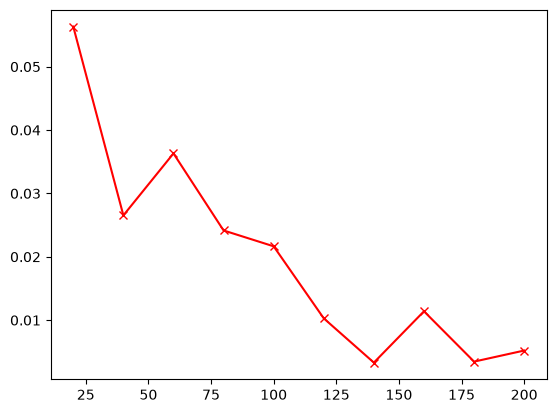

In [13]:
#Miremos cómo a medida que aumentamos el número de lanzamientos, la distancia KL debería acercarse a cero, indicando que la distribución experimental se aproxima a la distribución uniforme teórica.
num=[int(ni) for ni in np.arange(20, 210, 20)]
KL=[]
for n in num:
    # 1. Simular 20 lanzamientos de un dado de 6 caras
    num_throws = n
    die_rolls = np.random.randint(1, 7, num_throws) # Dado de 6 caras (1 a 6)
    counts = pd.Series(die_rolls).value_counts().sort_index()
    all_faces = np.arange(1, 7)
    experimental_counts = counts.reindex(all_faces, fill_value=0)
    experimental_probs = experimental_counts / num_throws
    uniform_probs = np.full(6, 1/6)
    kl_divergence = kl_discrete(experimental_probs.values, uniform_probs)
    KL.append(kl_divergence)
plt.plot(num,KL, 'x-r')